# Clustering Method Comparison

Compare K-Means, DBSCAN, hierarchical clustering, and GMM using the prepared customer features.



## Notebook Guide
This notebook compares K-means against alternative clustering methods to see whether the chosen segmentation remains the most stable and interpretable option.


In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'dataset'
GENERATED_DIR = PROJECT_ROOT / 'generated'
FIGURES_DIR = PROJECT_ROOT / 'figures'

GENERATED_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset dir: {DATA_DIR}')
print(f'Generated dir: {GENERATED_DIR}')
print(f'Figures dir: {FIGURES_DIR}')

import pandas as pd
customer_features = pd.read_csv(GENERATED_DIR / 'customer_features_prepared.csv')
pd.set_option('display.max_columns', None)
print(f"Loaded customer_features: {customer_features.shape}")


Project root: /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis
Dataset dir: /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/dataset
Generated dir: /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/generated
Figures dir: /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures
Loaded customer_features: (121112, 26)


## PART X: ALTERNATIVE CLUSTERING METHODS
Frame the comparison between the baseline K-means model and the alternative approaches.


In [2]:
# ============================================================================
# PART X: ALTERNATIVE CLUSTERING METHODS
# DBSCAN  ·  Agglomerative Hierarchical  ·  Gaussian Mixture Model (GMM)
# + Full comparison with K-Means (k=4)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster        import DBSCAN, AgglomerativeClustering
from sklearn.mixture        import GaussianMixture
from sklearn.decomposition  import PCA
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (silhouette_score, davies_bouldin_score,
                                    calinski_harabasz_score, adjusted_rand_score,
                                    normalized_mutual_info_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance  import cdist

print("✓ All imports loaded.")


✓ All imports loaded.


## SHARED SETUP
Prepare one consistent feature matrix so each algorithm is evaluated on the same footing.


In [3]:
# ============================================================================
# SHARED SETUP — feature matrix used by all methods
# ============================================================================
# Mirrors the original K-Means exactly:
#   X_cols      = [transactions_per_month, avg_basket_value, recency_days]
#   combinaison = mean of scaled X_cols  (already on customer_features)
#   Clustering input = profile_metrics + combinaison
#     where profile_metrics = all_metrics - X_cols
# ============================================================================

all_metrics = [
    "recency_days",
    "CD_TICKET_UNIQUE_total_transactions",
    "MT_TTC_NET_total_spend",
    "avg_basket_value",
    "transactions_per_month",
    "promo_percentage",
    "product_diversity_score",
    "store_loyalty_score",
]

X_cols = ["transactions_per_month", "avg_basket_value", "recency_days"]

# Rebuild combinaison (mean of scaled X_cols) in case this cell runs standalone
_x_df = customer_features[X_cols].select_dtypes(include=[np.number]).copy()
_x_df.fillna(_x_df.median(), inplace=True)
_scaler_comb = StandardScaler()
_x_scaled = _scaler_comb.fit_transform(_x_df)
customer_features["combinaison"] = np.nan
customer_features.loc[_x_df.index, "combinaison"] = _x_scaled.mean(axis=1)
print("✓ combinaison rebuilt")

# Clustering features = profile_metrics + combinaison  (same as original K-Means)
profile_metrics = [col for col in all_metrics if col not in X_cols]
CLUSTERING_FEATURES = profile_metrics + ["combinaison"]
CLUSTERING_FEATURES = [f for f in CLUSTERING_FEATURES if f in customer_features.columns]

print(f"Clustering features ({len(CLUSTERING_FEATURES)}): {CLUSTERING_FEATURES}")

df_clust = customer_features[CLUSTERING_FEATURES].copy()
df_clust.fillna(df_clust.median(), inplace=True)
for col in df_clust.columns:
    median_val = df_clust[col].median()
    df_clust[col] = df_clust[col].replace([np.inf, -np.inf], median_val)

scaler_shared = StandardScaler()
X = scaler_shared.fit_transform(df_clust)

# PCA for 2-D visualisation (computed once, reused by all methods)
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X)
var_explained = pca2.explained_variance_ratio_.sum()

print(f"Feature matrix : {X.shape}")
print(f"PCA 2-D variance explained : {var_explained:.1%}")

# K-Means labels (k=4) — reference baseline
from sklearn.cluster import KMeans
km_ref = KMeans(n_clusters=4, random_state=42, n_init=20, max_iter=500)
labels_kmeans = km_ref.fit_predict(X)
print(f"K-Means (k=4) — Silhouette: {silhouette_score(X, labels_kmeans):.3f}")


✓ combinaison rebuilt
Clustering features (6): ['CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score', 'combinaison']
Feature matrix : (121112, 6)
PCA 2-D variance explained : 69.2%
K-Means (k=4) — Silhouette: 0.374


## DBSCAN
Test whether density-based clustering uncovers useful structure without forcing every customer into a cluster.


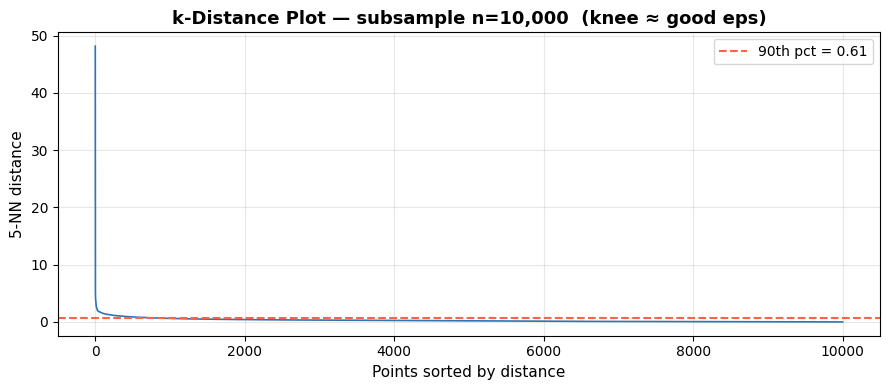

Top-10 DBSCAN configurations:
 eps  min_samples  n_clusters  noise_pct  silhouette  davies_bouldin
 1.2           10           2        0.3    0.291960        1.161130
 1.2           20           2        0.5    0.288524        1.155955
 1.2            5           4        0.2    0.282770        0.732489
 1.2           30           2        0.6    0.282165        1.153435
 0.3           20          17       16.5    0.207569        1.173139
 0.3           30          16       19.5    0.175484        1.210295
 0.8           30          10        2.2    0.172688        2.071160
 1.0           30          11        1.2    0.169802        2.210655
 0.7            5          37        1.0    0.168719        1.224243
 0.8            5          27        0.7    0.167724        1.451376
Best DBSCAN: eps=1.2, min_samples=10
  Clusters found : 2
  Noise points   : 360 (0.3%)
  Silhouette     : 0.292
  Davies-Bouldin : 1.161


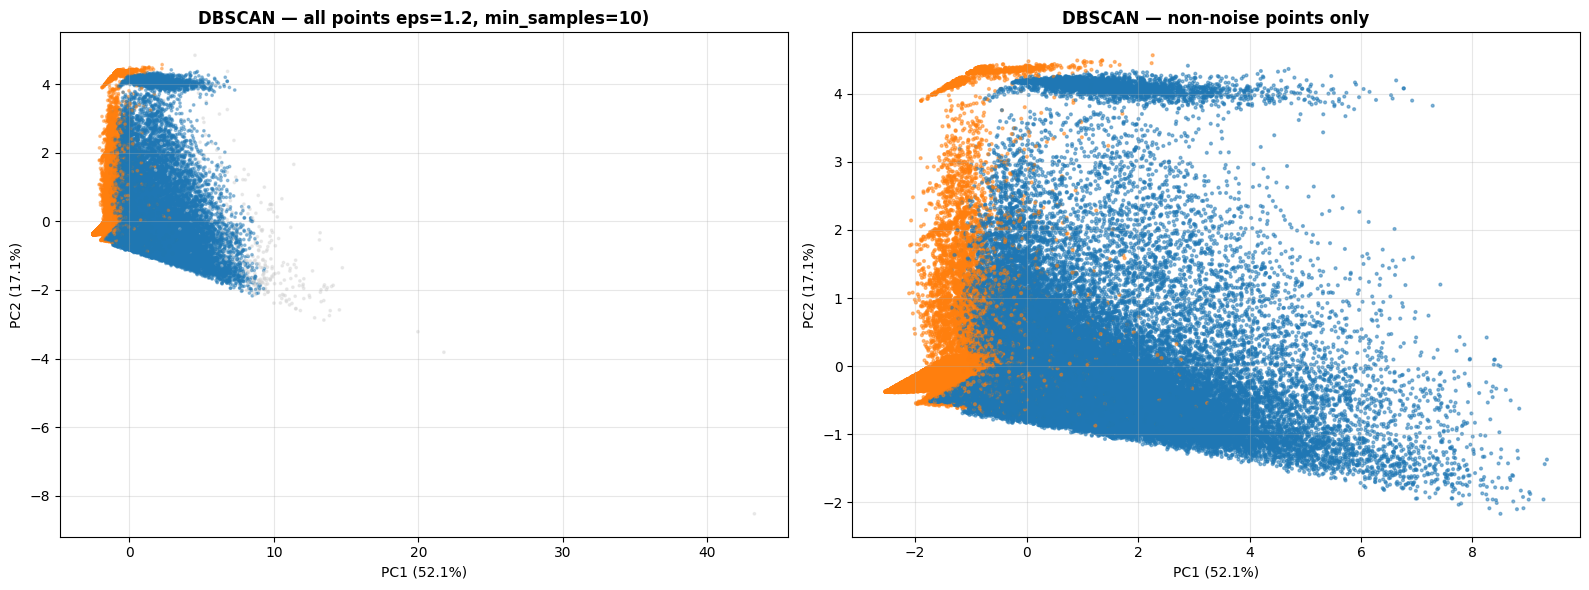

✓ DBSCAN complete.


In [4]:
# ============================================================================
# DBSCAN  — Density-Based Spatial Clustering
# ============================================================================
# Optimised for 121k rows:
#   • k-distance plot on a 10k subsample (representative, ~12x faster)
#   • Grid search uses sample_size in silhouette_score
#   • n_jobs=-1 throughout
# ============================================================================

from sklearn.neighbors import NearestNeighbors

# --- 1) k-distance plot on subsample ----------------------------------------
K_NN        = 5
KDIST_N     = 10_000   # subsample for k-distance plot

np.random.seed(42)
_idx_kd  = np.random.choice(len(X), size=KDIST_N, replace=False)
X_kd     = X[_idx_kd]

nbrs     = NearestNeighbors(n_neighbors=K_NN, n_jobs=-1).fit(X_kd)
dists, _ = nbrs.kneighbors(X_kd)
k_dist   = np.sort(dists[:, K_NN - 1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_dist, linewidth=1.2, color="#2E75B6")
ax.set_xlabel("Points sorted by distance", fontsize=11)
ax.set_ylabel(f"{K_NN}-NN distance", fontsize=11)
ax.set_title(f"k-Distance Plot — subsample n={KDIST_N:,}  (knee ≈ good eps)",
             fontsize=13, fontweight="bold")
_pct90 = np.percentile(k_dist, 90)
ax.axhline(y=_pct90, color="tomato", linestyle="--",
           label=f"90th pct = {_pct90:.2f}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dbscan_kdist.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 2) Grid search with fast silhouette ------------------------------------
# silhouette_score uses sample_size=5k to avoid O(n²) computation
EPS_GRID      = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2]
MINSAMP_GRID  = [5, 10, 20, 30]
SIL_SAMPLE    = 5_000

results_db = []
for eps in EPS_GRID:
    for ms in MINSAMP_GRID:
        lbl        = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(X)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct  = (lbl == -1).mean() * 100
        if n_clusters >= 2 and noise_pct < 30:
            mask = lbl != -1
            sil  = silhouette_score(X[mask], lbl[mask],
                                    sample_size=min(SIL_SAMPLE, mask.sum()),
                                    random_state=42)
            dbs  = davies_bouldin_score(X[mask], lbl[mask])
            results_db.append(dict(eps=eps, min_samples=ms,
                                   n_clusters=n_clusters, noise_pct=round(noise_pct,1),
                                   silhouette=sil, davies_bouldin=dbs))

df_db_grid = pd.DataFrame(results_db).sort_values("silhouette", ascending=False)
print("Top-10 DBSCAN configurations:")
print(df_db_grid.head(10).to_string(index=False))

# --- 3) Best configuration --------------------------------------------------
best_db      = df_db_grid.iloc[0]
best_eps     = best_db["eps"]
best_ms      = int(best_db["min_samples"])
labels_dbscan = DBSCAN(eps=best_eps, min_samples=best_ms, n_jobs=-1).fit_predict(X)

print(f"Best DBSCAN: eps={best_eps}, min_samples={best_ms}")
print(f"  Clusters found : {int(best_db['n_clusters'])}")
print(f"  Noise points   : {(labels_dbscan==-1).sum():,} ({(labels_dbscan==-1).mean()*100:.1f}%)")
print(f"  Silhouette     : {best_db['silhouette']:.3f}")
print(f"  Davies-Bouldin : {best_db['davies_bouldin']:.3f}")

# --- 4) PCA plots -----------------------------------------------------------
cmap_db       = plt.get_cmap("tab10")
color_list_db = ["lightgrey" if l == -1 else cmap_db(l % 10) for l in labels_dbscan]
mask_nn       = labels_dbscan != -1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=color_list_db, s=3, alpha=0.4, rasterized=True)
axes[0].set_title(f"DBSCAN — all points eps={best_eps}, min_samples={best_ms})",fontsize=12, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")

axes[1].scatter(X_pca[mask_nn, 0], X_pca[mask_nn, 1],
                c=[cmap_db(l % 10) for l in labels_dbscan[mask_nn]],
                s=4, alpha=0.5, rasterized=True)
axes[1].set_title("DBSCAN — non-noise points only", fontsize=12, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")

for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dbscan_pca.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()
print("✓ DBSCAN complete.")


## AGGLOMERATIVE HIERARCHICAL CLUSTERING
Measure how a bottom-up clustering strategy partitions the customer base.


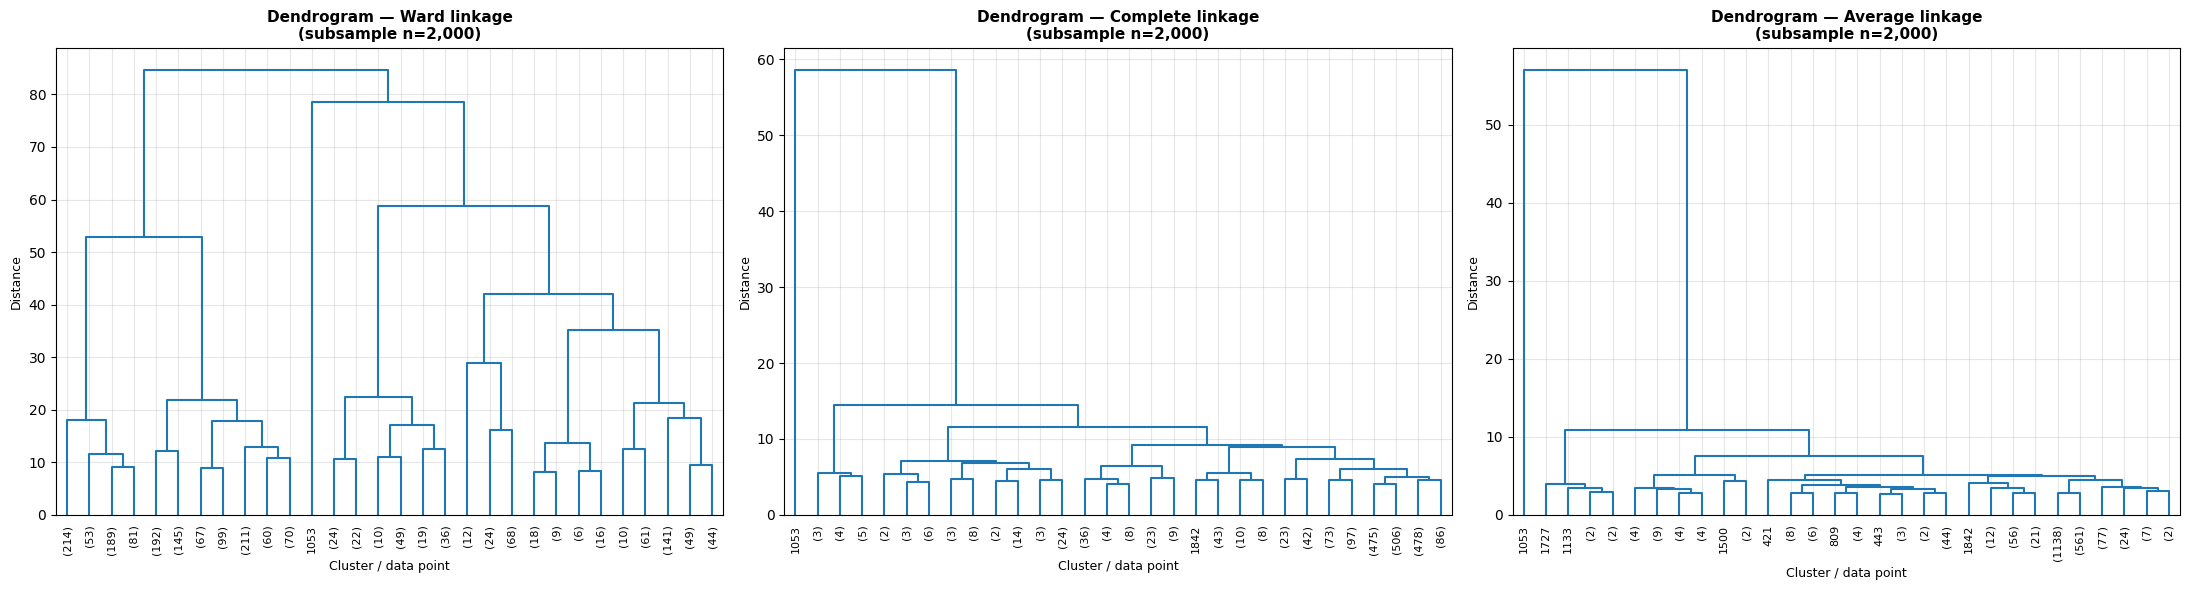

AHC fit sample : (20000, 6)  |  full dataset : (121112, 6)

Silhouette scores — linkage comparison (k=4, sample n=20k):
  ward      : Silhouette=0.345  Davies-Bouldin=1.056
  complete  : Silhouette=0.678  Davies-Bouldin=0.301
  average   : Silhouette=0.722  Davies-Bouldin=0.429

Best linkage: average

Propagating cluster labels to 121,112 customers via 5-NN...
✓ Labels propagated to full dataset

k-sweep (ward linkage, sample n=20k):
  k=2: Silhouette=0.455
  k=3: Silhouette=0.298
  k=4: Silhouette=0.345
  k=5: Silhouette=0.259
  k=6: Silhouette=0.265
  k=7: Silhouette=0.270
  k=8: Silhouette=0.271


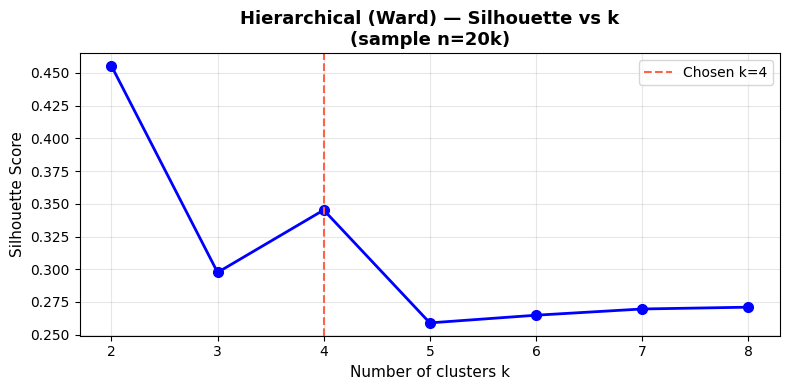

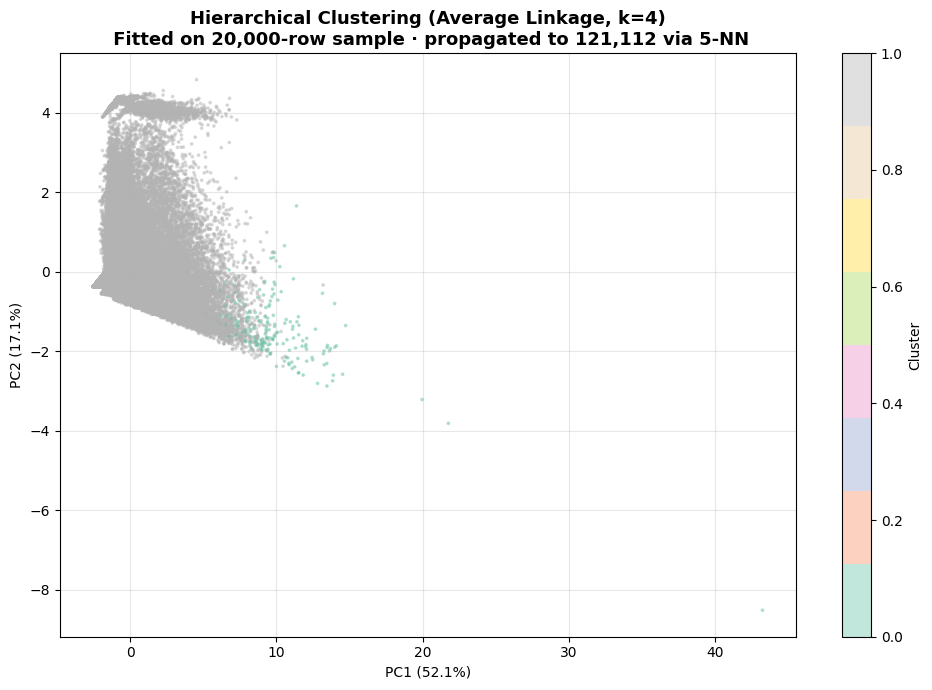


Cluster distribution (hierarchical, average, full 121,112 customers):
  Cluster 0: 210  (0.2%)
  Cluster 1: 120,902  (99.8%)
✓ Hierarchical clustering complete.


In [5]:
# ============================================================================
# AGGLOMERATIVE HIERARCHICAL CLUSTERING
# ============================================================================
# AHC memory crash at 121k rows:
#   sklearn AgglomerativeClustering builds a full merge tree — O(n^2) RAM.
#   Fix: fit on a 20k stratified sample, propagate labels to all 121k via KNN.
#   Dendrogram uses 2k subsample (linkage matrix itself is O(n^2) — keep tiny).
#   k-sweep and linkage comparison run on the 20k sample for consistency.
# ============================================================================

from sklearn.neighbors import KNeighborsClassifier

HIER_K     = 4
HIER_N     = 20_000   # sample size for AHC fit  (safe RAM budget)
DENDRO_N   = 2_000    # sample size for dendrogram only
SIL_SAMPLE = 5_000

# --- 1) Dendrogram on 2k subsample ------------------------------------------
np.random.seed(42)
_idx_d = np.random.choice(len(X), size=DENDRO_N, replace=False)
X_sub  = X[_idx_d]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, method in zip(axes, ["ward", "complete", "average"]):
    Z = linkage(X_sub, method=method)
    dendrogram(Z, ax=ax, truncate_mode="lastp", p=30,
               leaf_rotation=90, leaf_font_size=8, color_threshold=0)
    ax.set_title(f"Dendrogram — {method.capitalize()} linkage\n(subsample n={DENDRO_N:,})",fontsize=11, fontweight="bold")
    ax.set_xlabel("Cluster / data point", fontsize=9)
    ax.set_ylabel("Distance", fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hierarchical_dendrograms.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 2) Draw 20k sample for AHC fit ----------------------------------------
np.random.seed(42)
idx_sample = np.random.choice(len(X), size=HIER_N, replace=False)
X_sample   = X[idx_sample]
print(f"AHC fit sample : {X_sample.shape}  |  full dataset : {X.shape}")

# --- 3) Compare linkage methods on the 20k sample ---------------------------
print("\nSilhouette scores — linkage comparison (k=4, sample n=20k):")
linkage_scores = {}
for method in ["ward", "complete", "average"]:
    lbl_s = AgglomerativeClustering(n_clusters=HIER_K, linkage=method).fit_predict(X_sample)
    sil   = silhouette_score(X_sample, lbl_s,
                             sample_size=min(SIL_SAMPLE, HIER_N), random_state=42)
    dbs   = davies_bouldin_score(X_sample, lbl_s)
    linkage_scores[method] = dict(silhouette=sil, davies_bouldin=dbs, labels_sample=lbl_s)
    print(f"  {method:10s}: Silhouette={sil:.3f}  Davies-Bouldin={dbs:.3f}")

best_linkage  = max(linkage_scores, key=lambda m: linkage_scores[m]["silhouette"])
labels_sample = linkage_scores[best_linkage]["labels_sample"]
print(f"\nBest linkage: {best_linkage}")

# --- 4) Propagate labels to full 121k via KNN -------------------------------
print(f"\nPropagating cluster labels to {len(X):,} customers via 5-NN...")
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_sample, labels_sample)
labels_hier = knn.predict(X)
print("✓ Labels propagated to full dataset")

# --- 5) k-sweep (ward on 20k sample) ----------------------------------------
print("\nk-sweep (ward linkage, sample n=20k):")
ward_sil = []
k_range  = range(2, 9)
for k in k_range:
    lbl_s = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_sample)
    sil   = silhouette_score(X_sample, lbl_s,
                             sample_size=min(SIL_SAMPLE, HIER_N), random_state=42)
    ward_sil.append(sil)
    print(f"  k={k}: Silhouette={sil:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), ward_sil, "bo-", linewidth=2, markersize=7)
ax.axvline(x=HIER_K, color="tomato", linestyle="--", label=f"Chosen k={HIER_K}")
ax.set_xlabel("Number of clusters k", fontsize=11)
ax.set_ylabel("Silhouette Score", fontsize=11)
ax.set_title("Hierarchical (Ward) — Silhouette vs k\n(sample n=20k)",fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hierarchical_silhouette_k.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 6) PCA plot — full 121k with propagated labels -------------------------
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=labels_hier, cmap="Set2", s=3, alpha=0.4, rasterized=True)
ax.set_title(
    f"Hierarchical Clustering ({best_linkage.capitalize()} Linkage, k={HIER_K})\n Fitted on {HIER_N:,}-row sample · propagated to {len(X):,} via 5-NN",fontsize=13, fontweight="bold"
)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc, label="Cluster"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hierarchical_pca.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

vals, cnts = np.unique(labels_hier, return_counts=True)
print(f"\nCluster distribution (hierarchical, {best_linkage}, full {len(X):,} customers):")
for v, c in zip(vals, cnts):
    print(f"  Cluster {v}: {c:,}  ({c/len(labels_hier)*100:.1f}%)")
print("✓ Hierarchical clustering complete.")


## GAUSSIAN MIXTURE MODEL (GMM)
Evaluate a probabilistic clustering approach that allows softer cluster boundaries.


  tied         — BIC min at k=4
  diag         — BIC min at k=8
  spherical    — BIC min at k=8
  full         — BIC at k=4: 196,009  (sweep skipped for speed)


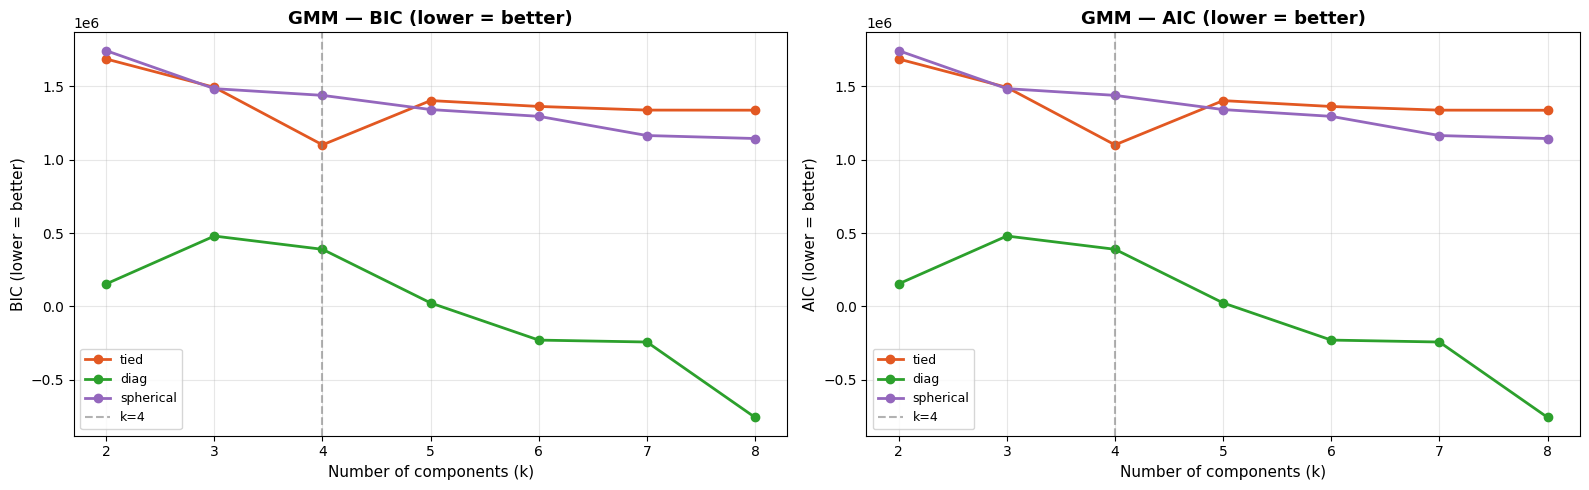

BIC at k=4 per covariance type:
  full        : 196,009  ← best
  diag        : 389,426  
  tied        : 1,101,939  
  spherical   : 1,439,522  
GMM (k=4, cov=full):
  Silhouette         : 0.254
  Davies-Bouldin     : 1.479
  Avg max P(cluster) : 0.978  (1.0 = perfectly certain)


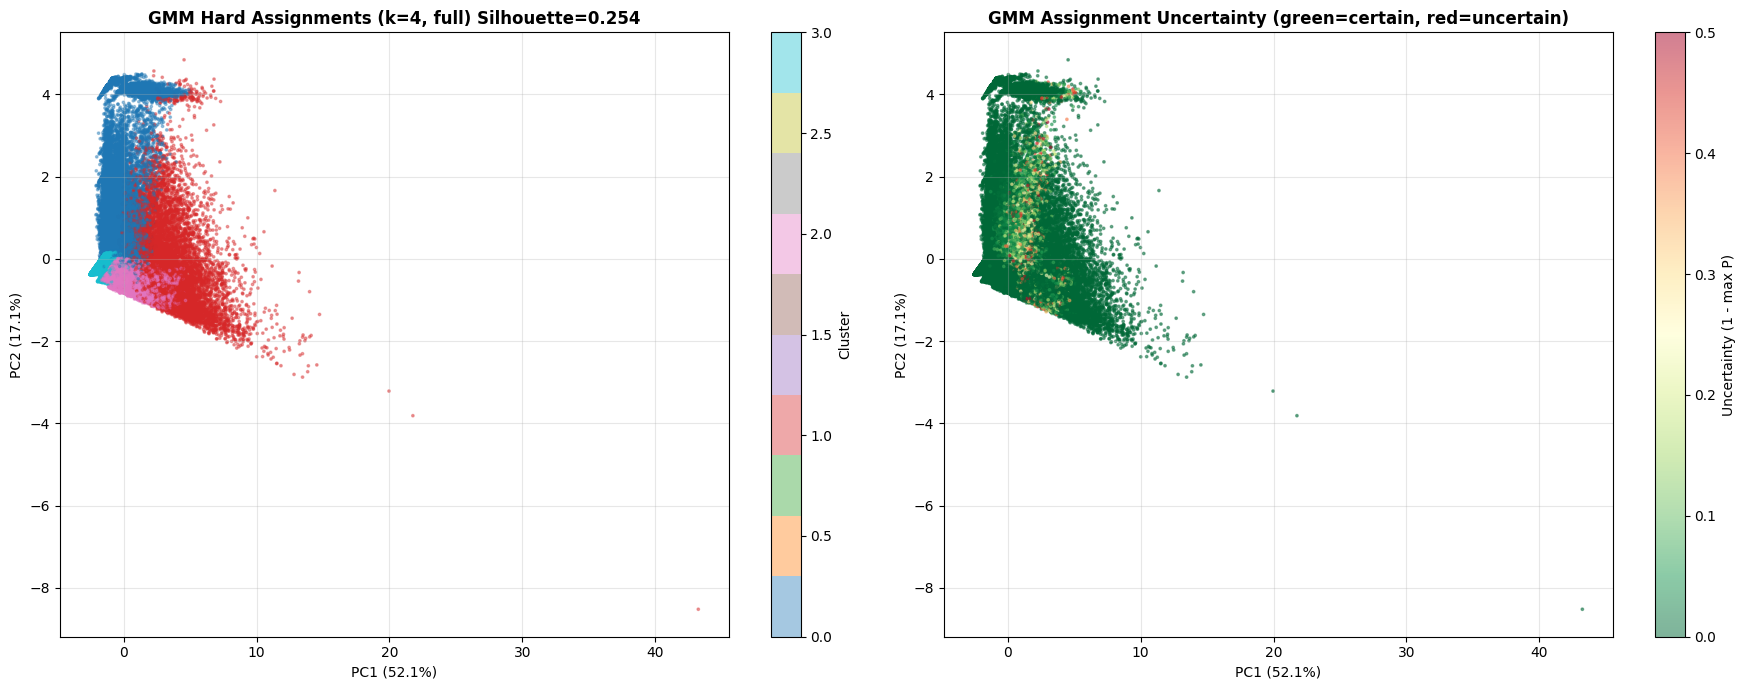

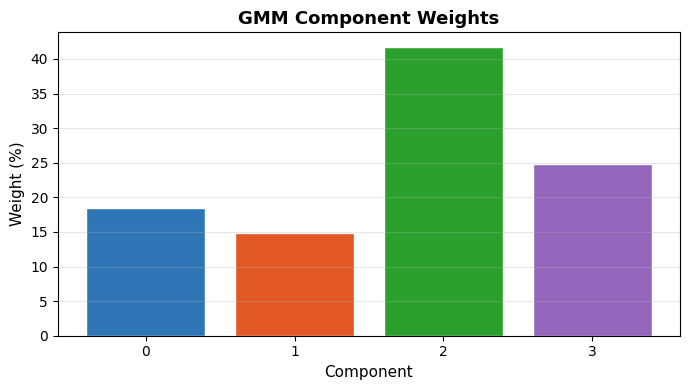

Cluster distribution (GMM):
  Cluster 0: 23,226 (19.2%)
  Cluster 1: 17,172 (14.2%)
  Cluster 2: 50,599 (41.8%)
  Cluster 3: 30,115 (24.9%)
✓ GMM complete.


In [6]:
# ============================================================================
# GAUSSIAN MIXTURE MODEL (GMM)
# ============================================================================
# Optimised for 121k rows:
#   • BIC/AIC sweep uses n_init=1 (sufficient for selection; full fit uses n_init=5)
#   • Covariance types: full dropped from sweep (very slow at 121k×6 features)
#     → included in final fit comparison only
#   • silhouette uses sample_size=5k
# ============================================================================

GMM_K      = 4
SIL_SAMPLE = 5_000

# --- 1) BIC / AIC sweep (diag, tied, spherical — skip full for speed) --------
cov_types_sweep = ["tied", "diag", "spherical"]
cov_types_all   = ["full", "tied", "diag", "spherical"]
k_range_gmm     = range(2, 9)

bic_results = {ct: [] for ct in cov_types_sweep}
aic_results = {ct: [] for ct in cov_types_sweep}

for ct in cov_types_sweep:
    for k in k_range_gmm:
        gm = GaussianMixture(n_components=k, covariance_type=ct,
                             random_state=42, max_iter=200, n_init=1)
        gm.fit(X)
        bic_results[ct].append(gm.bic(X))
        aic_results[ct].append(gm.aic(X))
    best_k_bic = k_range_gmm[np.argmin(bic_results[ct])]
    print(f"  {ct:12s} — BIC min at k={best_k_bic}")

# Add full covariance at GMM_K only (expensive to sweep)
_gm_full = GaussianMixture(n_components=GMM_K, covariance_type="full",
                           random_state=42, max_iter=200, n_init=1)
_gm_full.fit(X)
bic_full_at_k = _gm_full.bic(X)
print(f"  {'full':12s} — BIC at k={GMM_K}: {bic_full_at_k:,.0f}  (sweep skipped for speed)")

# --- 2) BIC / AIC plots -----------------------------------------------------
colors_gmm = ["#E25822", "#2CA02C", "#9467BD"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, ct in enumerate(cov_types_sweep):
    axes[0].plot(list(k_range_gmm), bic_results[ct], "o-",
                 color=colors_gmm[i], label=ct, linewidth=2)
    axes[1].plot(list(k_range_gmm), aic_results[ct], "o-",
                 color=colors_gmm[i], label=ct, linewidth=2)
for ax, title in zip(axes, ["BIC (lower = better)", "AIC (lower = better)"]):
    ax.axvline(x=GMM_K, color="grey", linestyle="--", alpha=0.6, label=f"k={GMM_K}")
    ax.set_xlabel("Number of components (k)", fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f"GMM — {title}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gmm_bic_aic.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 3) Select best covariance type at GMM_K --------------------------------
bic_at_k = {ct: bic_results[ct][GMM_K - 2] for ct in cov_types_sweep}
bic_at_k["full"] = bic_full_at_k
best_cov = min(bic_at_k, key=bic_at_k.get)
print(f"BIC at k={GMM_K} per covariance type:")
for ct, v in sorted(bic_at_k.items(), key=lambda x: x[1]):
    print(f"  {ct:12s}: {v:,.0f}  {'← best' if ct==best_cov else ''}")

# --- 4) Final GMM fit --------------------------------------------------------
gmm_best   = GaussianMixture(n_components=GMM_K, covariance_type=best_cov,
                             random_state=42, max_iter=500, n_init=5)
gmm_best.fit(X)
labels_gmm = gmm_best.predict(X)
proba_gmm  = gmm_best.predict_proba(X)
max_proba  = proba_gmm.max(axis=1)

sil_gmm = silhouette_score(X, labels_gmm, sample_size=SIL_SAMPLE, random_state=42)
db_gmm  = davies_bouldin_score(X, labels_gmm)
print(f"GMM (k={GMM_K}, cov={best_cov}):")
print(f"  Silhouette         : {sil_gmm:.3f}")
print(f"  Davies-Bouldin     : {db_gmm:.3f}")
print(f"  Avg max P(cluster) : {max_proba.mean():.3f}  (1.0 = perfectly certain)")

# --- 5) PCA scatter + uncertainty -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=labels_gmm, cmap="tab10", s=3, alpha=0.4, rasterized=True)
axes[0].set_title(f"GMM Hard Assignments (k={GMM_K}, {best_cov}) Silhouette={sil_gmm:.3f}", fontsize=12, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc, ax=axes[0], label="Cluster")

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=1 - max_proba, cmap="RdYlGn_r", s=3, alpha=0.5,
                      vmin=0, vmax=0.5, rasterized=True)
axes[1].set_title("GMM Assignment Uncertainty (green=certain, red=uncertain)", fontsize=12, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc2, ax=axes[1], label="Uncertainty (1 - max P)")

for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gmm_pca.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

# --- 6) Component weights ---------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(GMM_K), gmm_best.weights_ * 100,
       color=["#2E75B6","#E25822","#2CA02C","#9467BD"][:GMM_K], edgecolor="white")
ax.set_xlabel("Component", fontsize=11); ax.set_ylabel("Weight (%)", fontsize=11)
ax.set_title("GMM Component Weights", fontsize=13, fontweight="bold")
ax.set_xticks(range(GMM_K)); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gmm_weights.png", dpi=130, bbox_inches="tight")
plt.show(); plt.close()

vals, cnts = np.unique(labels_gmm, return_counts=True)
print("Cluster distribution (GMM):")
for v, c in zip(vals, cnts):
    print(f"  Cluster {v}: {c:,} ({c/len(labels_gmm)*100:.1f}%)")
print("✓ GMM complete.")


## FULL COMPARISON
Compare the main methods side by side using the same quality criteria.


CLUSTERING COMPARISON TABLE
                             Clusters  Noise  Silhouette  Davies_Bouldin  Calinski_Harabasz
Method                                                                                     
K-Means (k=4)                       4      0       0.370           1.006          54765.427
DBSCAN (best)                       2    360       0.292           1.161          40359.436
Hierarchical (average, k=4)         2      0       0.796           0.716           4661.179
GMM (k=4, full)                     4      0       0.254           1.479          34661.901

Notes:
  Silhouette        → higher is better  (range -1 to 1)
  Davies-Bouldin    → lower  is better  (≥ 0)
  Calinski-Harabasz → higher is better  (> 0, unbounded)


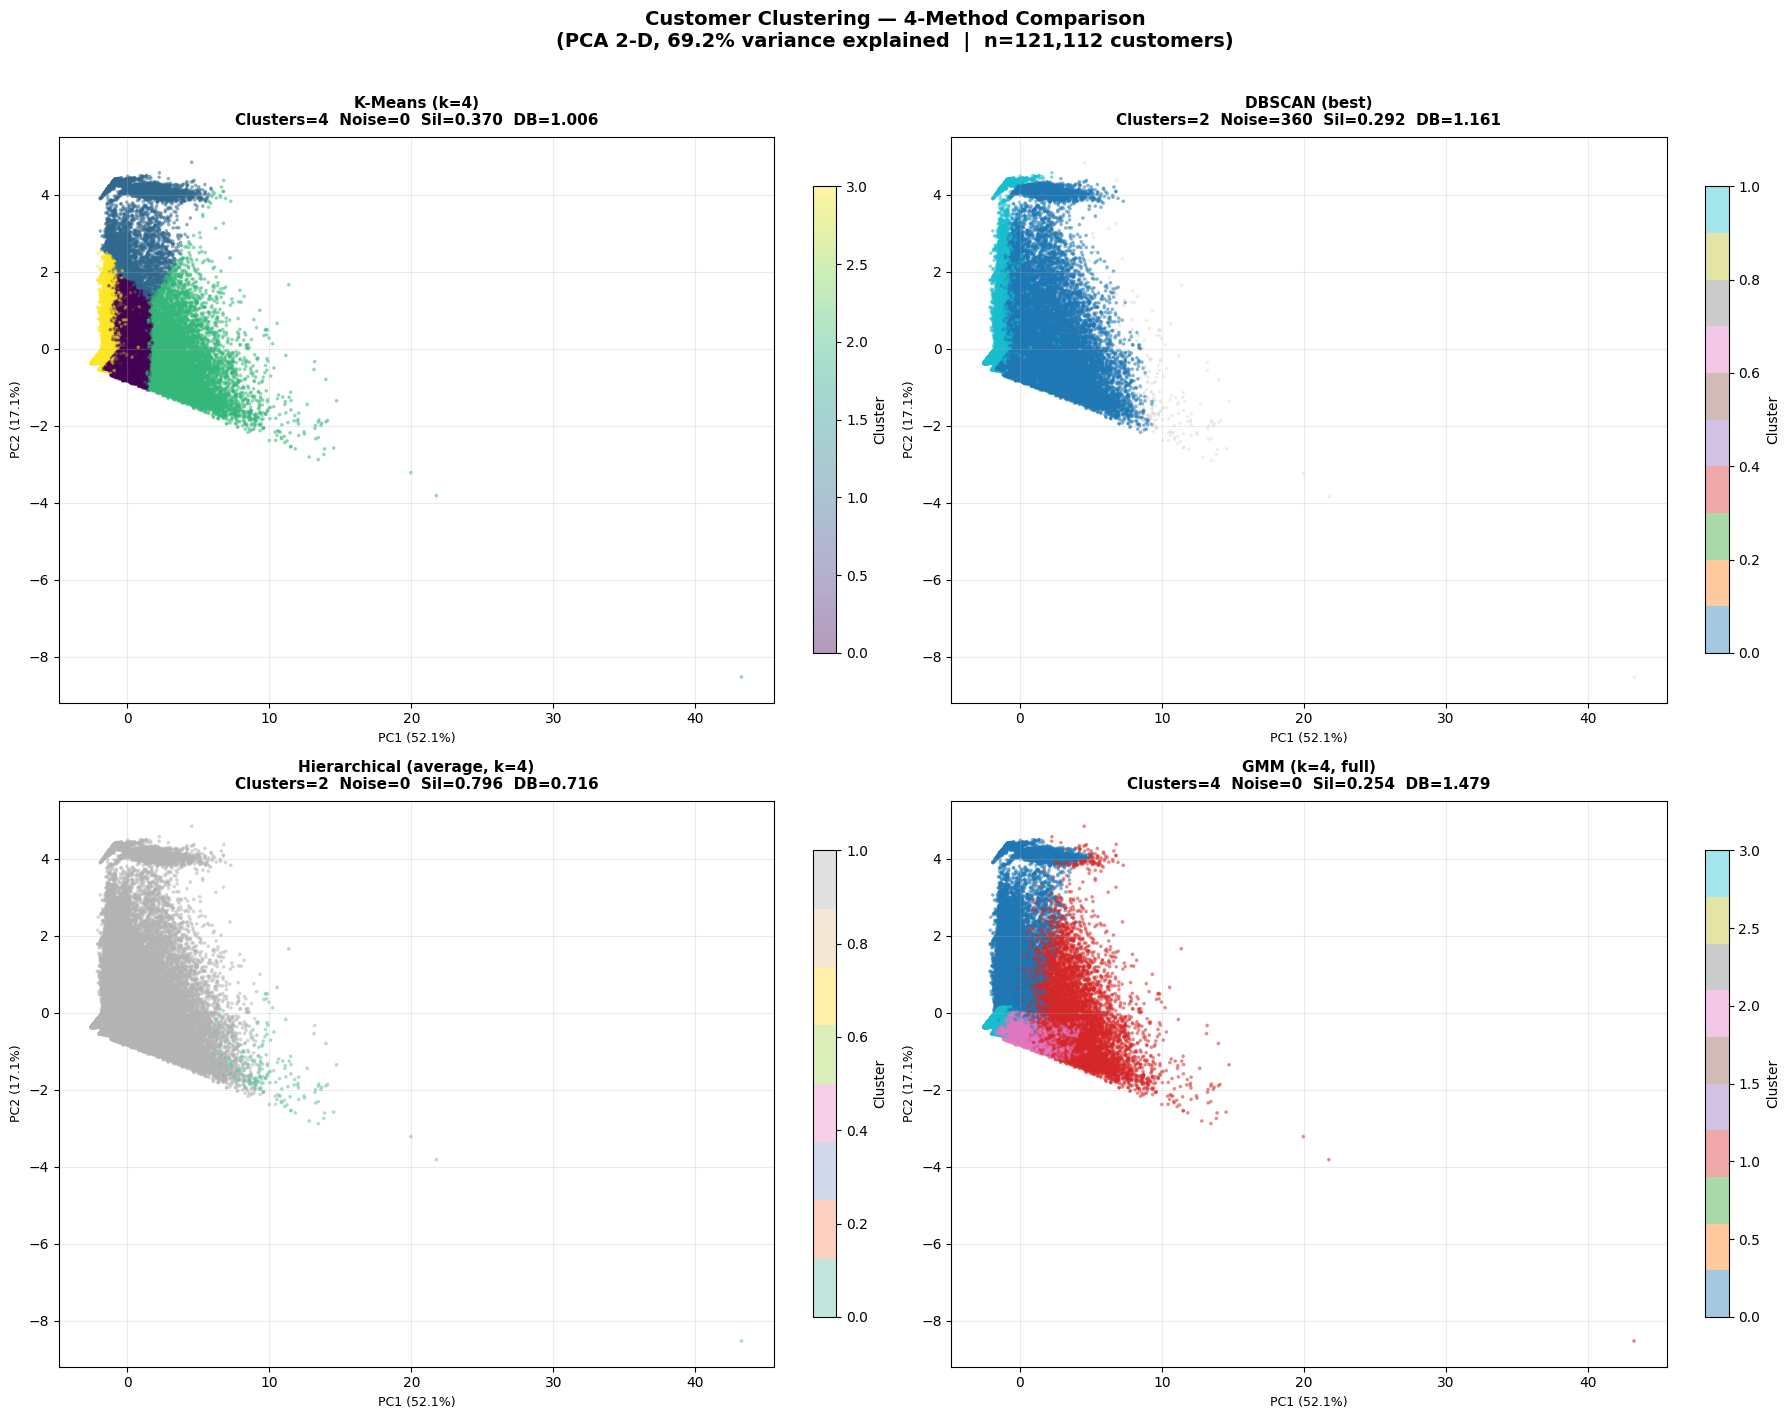

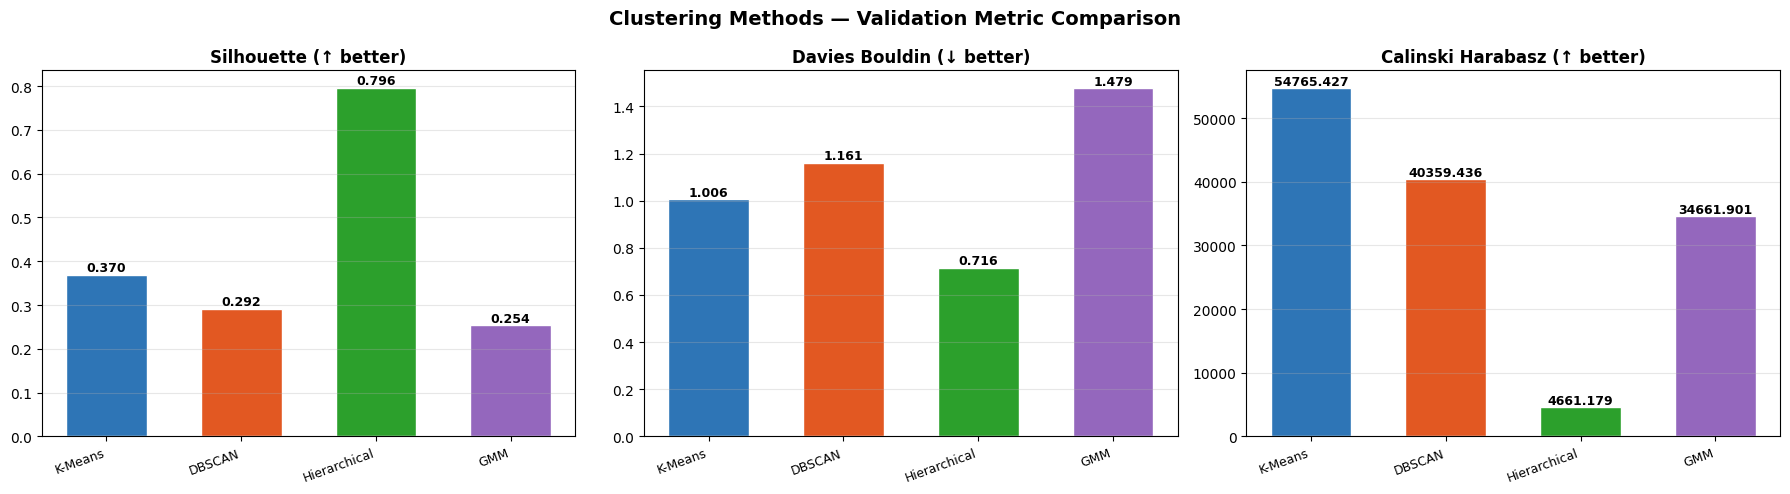

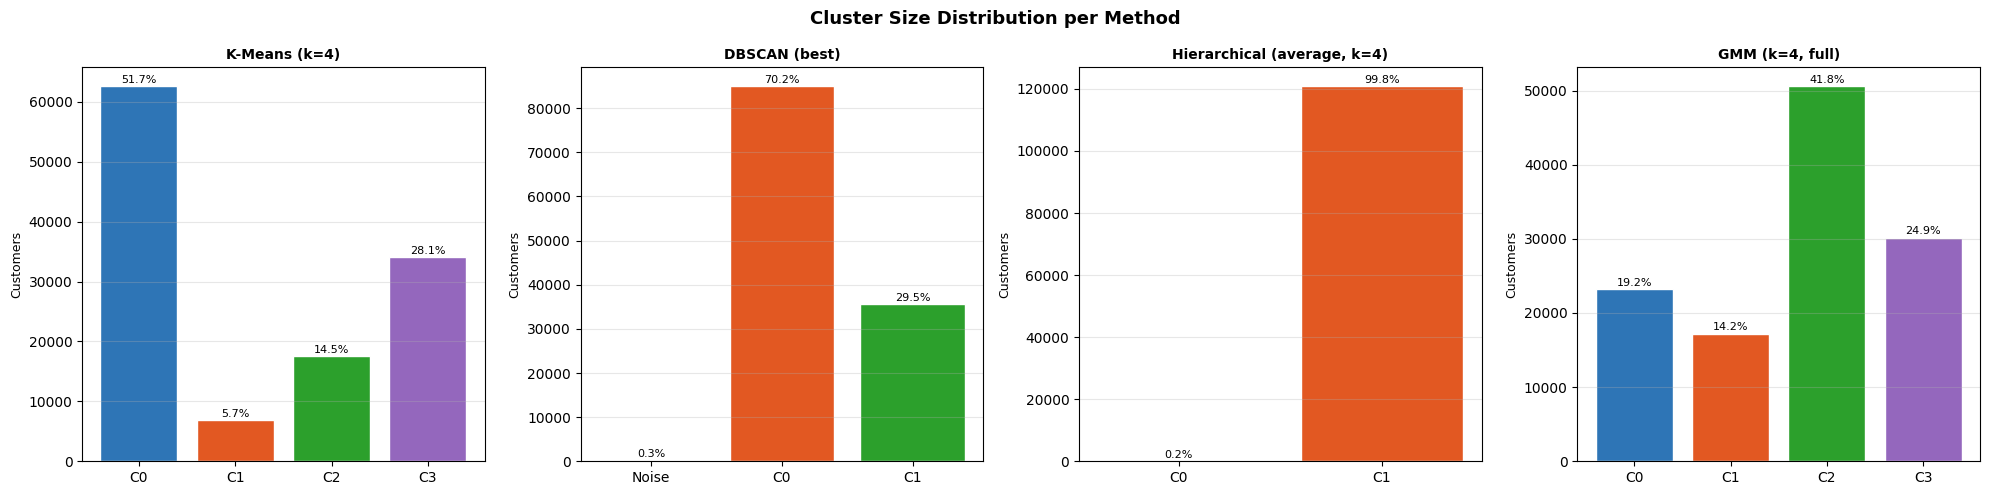

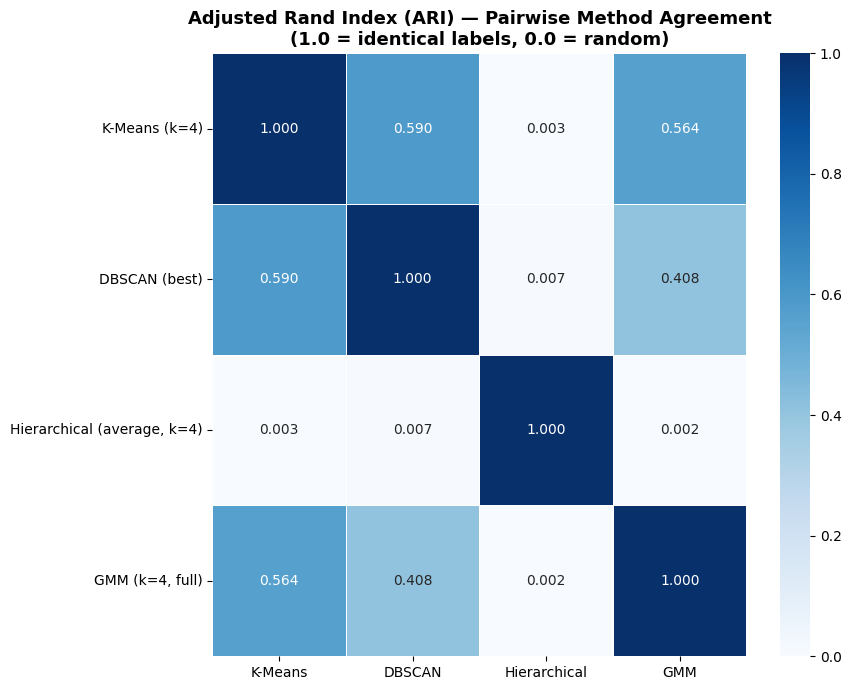


✓ All comparison plots saved.

Files generated:
  • /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures/dbscan_kdist.png
  • dbscan_pca.png
  • /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures/hierarchical_dendrograms.png
  • /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures/hierarchical_silhouette_k.png
  • /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures/hierarchical_pca.png
  • /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures/gmm_bic_aic.png
  • /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures/gmm_pca.png
  • /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures/gmm_weights.png
  • /Users/ponnimuthukumarasamy/Downloads/Prosol Dataset Complete/Sales-Data-Analysis/figures/clustering_comparison_pca.png
  • /User

In [7]:
# ============================================================================
# FULL COMPARISON — K-Means vs DBSCAN vs Hierarchical vs GMM
# ============================================================================

# ---- 0) Utility: safe silhouette (skip if <2 clusters after noise removal) --
def safe_sil(X, lbl, sample=5_000):
    mask = lbl != -1
    u = np.unique(lbl[mask])
    if len(u) < 2: return np.nan
    return silhouette_score(X[mask], lbl[mask], sample_size=min(5_000, mask.sum()),
                            random_state=42)

def safe_db(X, lbl):
    mask = lbl != -1
    u = np.unique(lbl[mask])
    if len(u) < 2: return np.nan
    return davies_bouldin_score(X[mask], lbl[mask])

def safe_ch(X, lbl):
    mask = lbl != -1
    u = np.unique(lbl[mask])
    if len(u) < 2: return np.nan
    return calinski_harabasz_score(X[mask], lbl[mask])

# ---- 1) Metric table --------------------------------------------------------
methods = {
    "K-Means (k=4)"          : labels_kmeans,
    "DBSCAN (best)"           : labels_dbscan,
    f"Hierarchical ({best_linkage}, k=4)" : labels_hier,
    f"GMM (k=4, {best_cov})"  : labels_gmm,
}

rows = []
for name, lbl in methods.items():
    n_clust  = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise    = (lbl == -1).sum()
    sil      = safe_sil(X, lbl)
    db       = safe_db(X, lbl)
    ch       = safe_ch(X, lbl)
    rows.append(dict(Method=name, Clusters=n_clust,
                     Noise=noise, Silhouette=sil,
                     Davies_Bouldin=db, Calinski_Harabasz=ch))

df_compare = pd.DataFrame(rows).set_index("Method")
print("=" * 90)
print("CLUSTERING COMPARISON TABLE")
print("=" * 90)
print(df_compare.round(3).to_string())
print()
print("Notes:")
print("  Silhouette        → higher is better  (range -1 to 1)")
print("  Davies-Bouldin    → lower  is better  (≥ 0)")
print("  Calinski-Harabasz → higher is better  (> 0, unbounded)")

# ---- 2) Side-by-side PCA plots (2×2 grid) -----------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()
titles = list(methods.keys())
cmaps  = ["viridis", "tab10", "Set2", "tab10"]

for ax, (name, lbl), cmap in zip(axes, methods.items(), cmaps):
    mask_plot = lbl != -1
    c_vals    = lbl[mask_plot]
    ax.scatter(X_pca[~mask_plot, 0], X_pca[~mask_plot, 1],
               c="lightgrey", s=2, alpha=0.3, rasterized=True, label="noise")
    sc = ax.scatter(X_pca[mask_plot, 0], X_pca[mask_plot, 1],
                    c=c_vals, cmap=cmap, s=3, alpha=0.4, rasterized=True)
    sil_val = df_compare.loc[name, "Silhouette"]
    db_val  = df_compare.loc[name, "Davies_Bouldin"]
    n_c     = df_compare.loc[name, "Clusters"]
    noise_n = df_compare.loc[name, "Noise"]
    ax.set_title(
        f"{name}\nClusters={n_c}  Noise={noise_n}  Sil={sil_val:.3f}  DB={db_val:.3f}",
        fontsize=11, fontweight="bold", pad=8
    )
    ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})", fontsize=9)
    ax.grid(alpha=0.25)
    plt.colorbar(sc, ax=ax, label="Cluster", fraction=0.03)

plt.suptitle(
    f"Customer Clustering — 4-Method Comparison\n"
    f"(PCA 2-D, {var_explained:.1%} variance explained  |  n={len(X):,} customers)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering_comparison_pca.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

# ---- 3) Metric radar / bar comparison ---------------------------------------
metrics_plot = ["Silhouette", "Davies_Bouldin", "Calinski_Harabasz"]
df_bar = df_compare[metrics_plot].copy()

# Normalise each metric 0–1 (Silhouette & CH: higher=better → keep raw rank)
# For DB: invert so that higher bar = better
df_norm = df_bar.copy()
df_norm["Davies_Bouldin"] = 1 / (1 + df_bar["Davies_Bouldin"])   # invert
df_norm["Silhouette"]     = (df_bar["Silhouette"] - df_bar["Silhouette"].min()) /                              (df_bar["Silhouette"].max() - df_bar["Silhouette"].min() + 1e-9)
df_norm["Calinski_Harabasz"] = (df_bar["Calinski_Harabasz"] - df_bar["Calinski_Harabasz"].min()) /                                 (df_bar["Calinski_Harabasz"].max() - df_bar["Calinski_Harabasz"].min() + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = ["#2E75B6", "#E25822", "#2CA02C", "#9467BD"]

for ax, metric in zip(axes, metrics_plot):
    vals_m = df_bar[metric].values
    bars = ax.bar(range(len(df_bar)), vals_m, color=bar_colors, edgecolor="white", width=0.6)
    ax.set_xticks(range(len(df_bar)))
    ax.set_xticklabels([m.split(" ")[0] for m in df_bar.index], rotation=20, ha="right", fontsize=9)
    arrow = "↑ better" if metric != "Davies_Bouldin" else "↓ better"
    ax.set_title(f"{metric.replace('_', ' ')} ({arrow})", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")
    for bar, val in zip(bars, vals_m):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Clustering Methods — Validation Metric Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering_metrics_comparison.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

# ---- 4) Cluster-size distribution comparison --------------------------------
fig, axes = plt.subplots(1, len(methods), figsize=(20, 5))
for ax, (name, lbl) in zip(axes, methods.items()):
    vals, cnts = np.unique(lbl, return_counts=True)
    clr = ["lightgrey" if v == -1 else bar_colors[i % len(bar_colors)]
           for i, v in enumerate(vals)]
    bars = ax.bar([f"C{v}" if v != -1 else "Noise" for v in vals],
                  cnts, color=clr, edgecolor="white")
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_ylabel("Customers", fontsize=9)
    ax.grid(alpha=0.3, axis="y")
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f"{cnt/len(lbl)*100:.1f}%", ha="center", va="bottom", fontsize=8)

plt.suptitle("Cluster Size Distribution per Method", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cluster_size_comparison.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

# ---- 5) Agreement heatmap (ARI matrix) -------------------------------------
method_names = list(methods.keys())
n_m = len(method_names)
ari_matrix = np.zeros((n_m, n_m))

for i, (n1, l1) in enumerate(methods.items()):
    for j, (n2, l2) in enumerate(methods.items()):
        ari_matrix[i, j] = adjusted_rand_score(l1, l2)

fig, ax = plt.subplots(figsize=(9, 7))
short_names = [n.split(" ")[0] for n in method_names]
sns.heatmap(ari_matrix, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=short_names, yticklabels=method_names,
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Adjusted Rand Index (ARI) — Pairwise Method Agreement\n"
             "(1.0 = identical labels, 0.0 = random)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering_ari_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

print("\n✓ All comparison plots saved.")
print("\nFiles generated:")
for f in [FIGURES_DIR / "dbscan_kdist.png", "dbscan_pca.png",
          FIGURES_DIR / "hierarchical_dendrograms.png", FIGURES_DIR / "hierarchical_silhouette_k.png",
          FIGURES_DIR / "hierarchical_pca.png", FIGURES_DIR / "gmm_bic_aic.png", FIGURES_DIR / "gmm_pca.png",
          FIGURES_DIR / "gmm_weights.png", FIGURES_DIR / "clustering_comparison_pca.png",
          FIGURES_DIR / "clustering_metrics_comparison.png", FIGURES_DIR / "cluster_size_comparison.png",
          FIGURES_DIR / "clustering_ari_heatmap.png"]:
    print(f"  • {f}")


## SEGMENT FEATURE PROFILES
Review how the customer profiles differ across the competing clustering strategies.


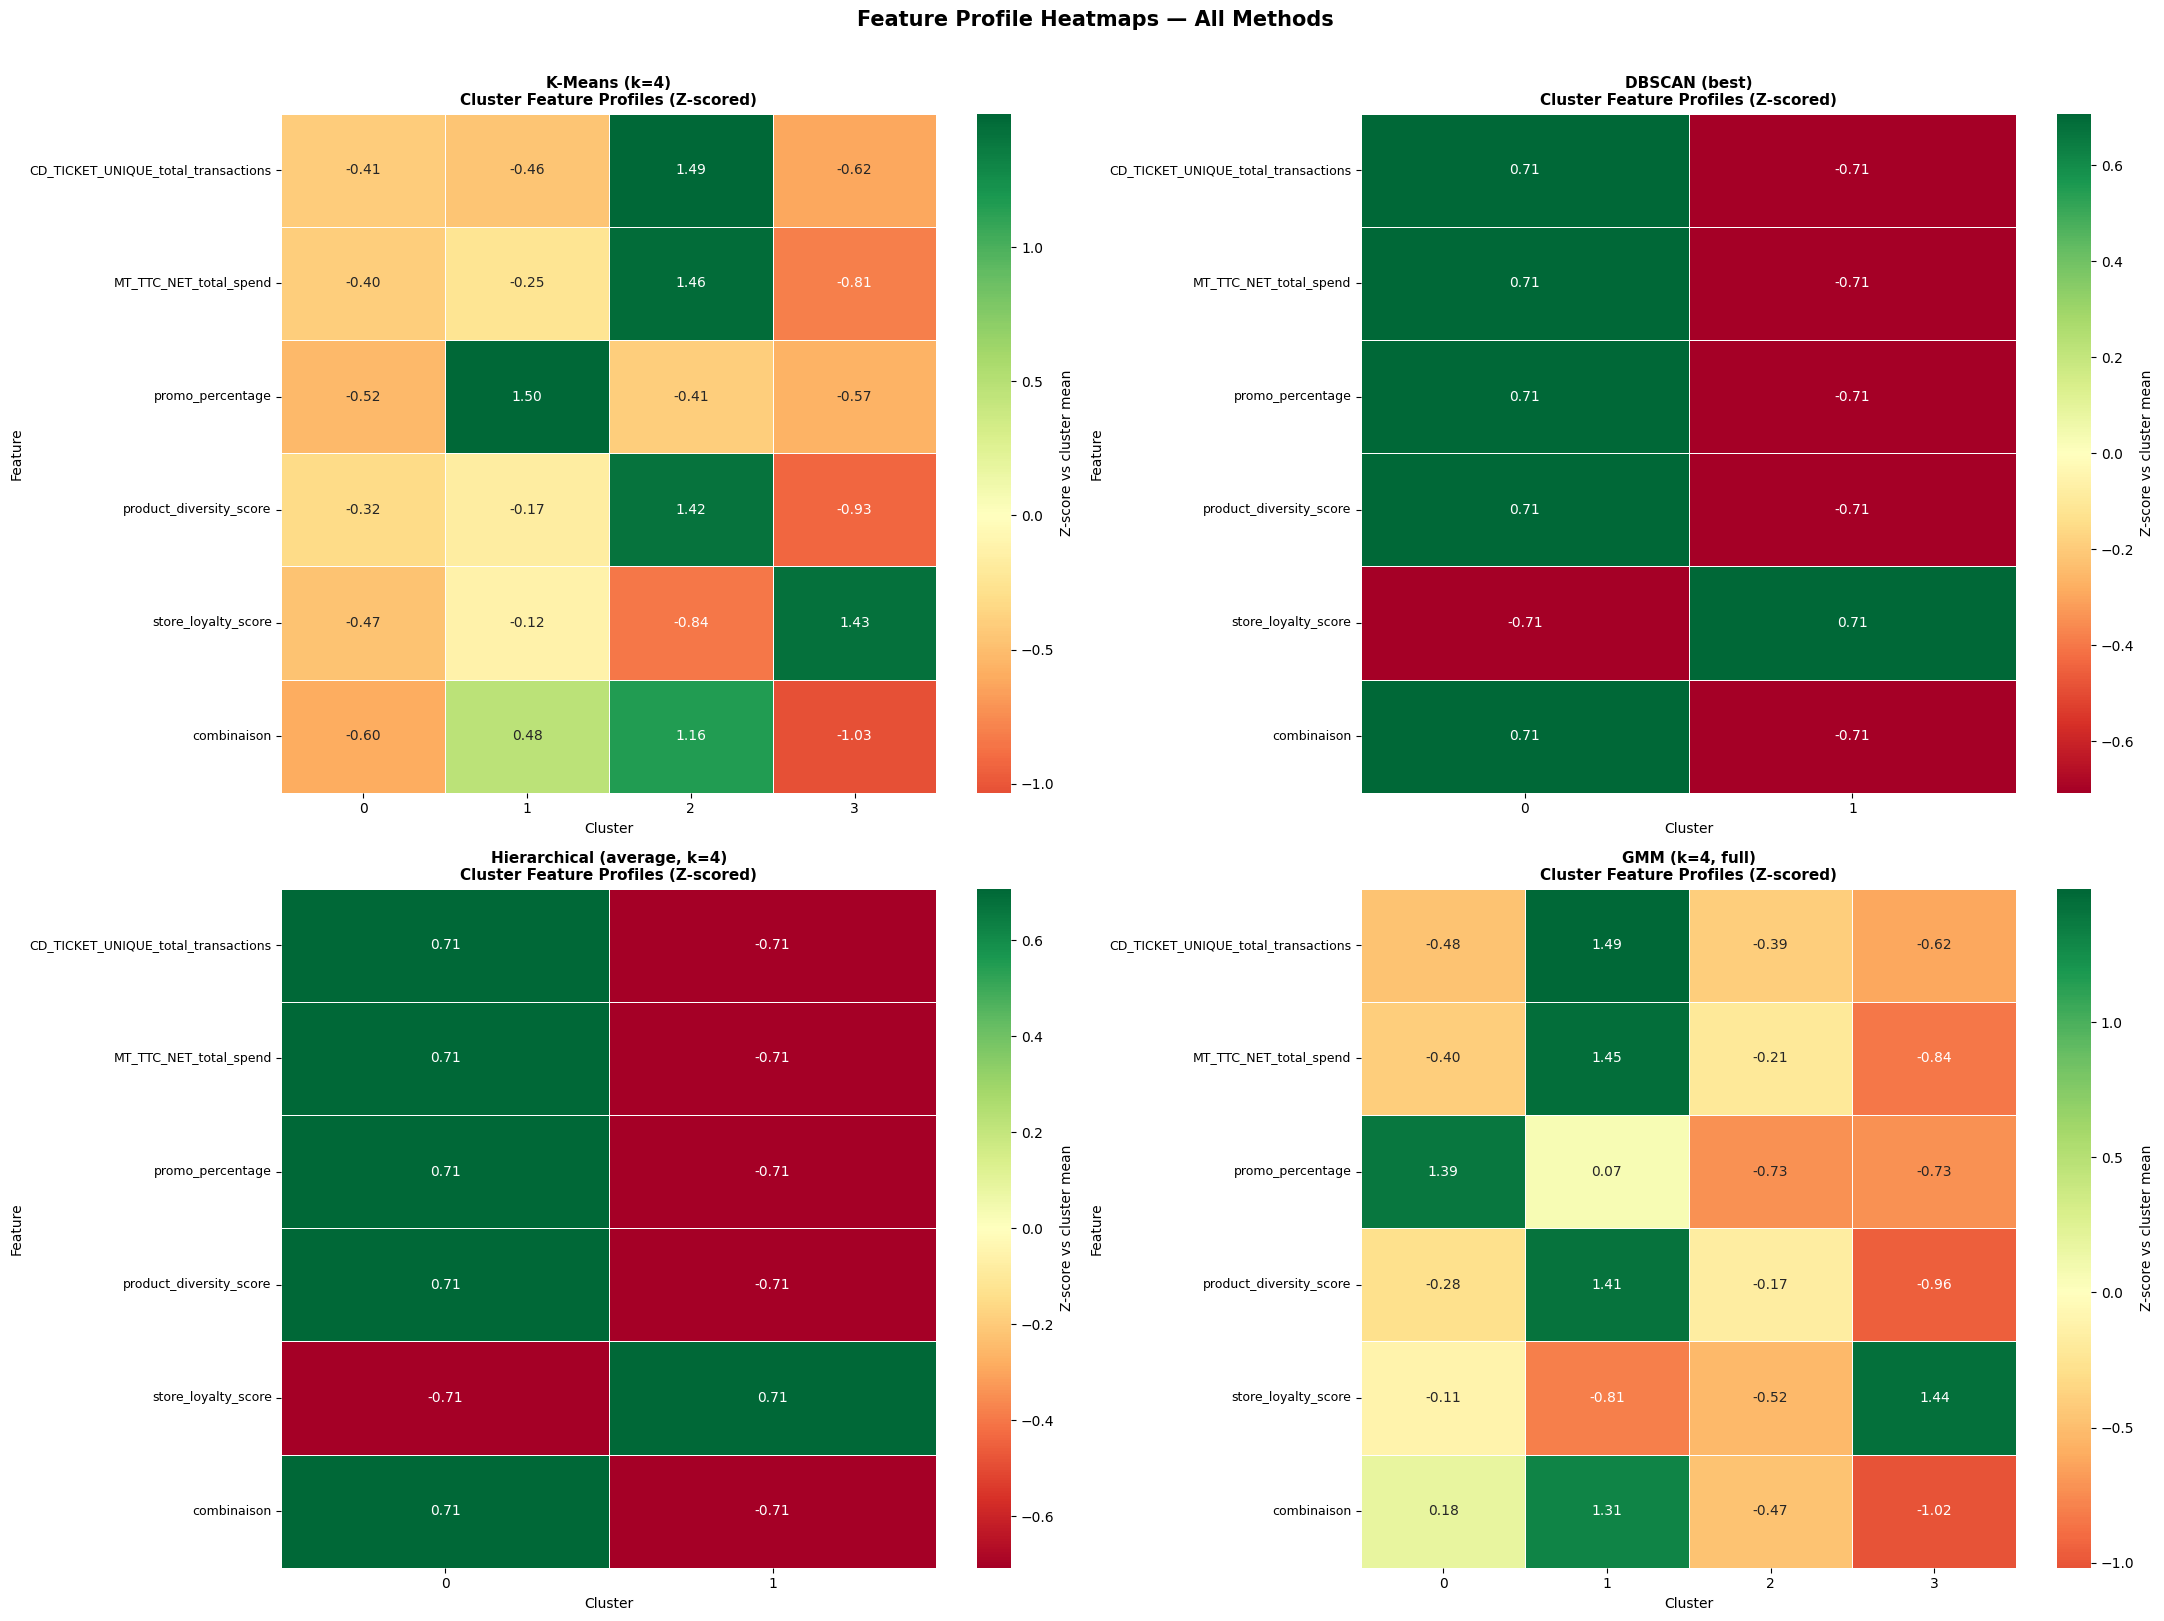


K-Means mean profiles (raw):
         CD_TICKET_UNIQUE_total_transactions  MT_TTC_NET_total_spend  promo_percentage  product_diversity_score  store_loyalty_score  combinaison
Cluster                                                                                                                                          
0                                       1.28                   32.15              4.43                    19.23                 0.43        -0.08
1                                       1.24                   38.65             86.75                    22.95                 0.53         0.37
2                                       2.66                  111.29              9.19                    63.37                 0.31         0.65
3                                       1.13                   14.88              2.67                     3.51                 1.00        -0.26

GMM mean profiles (raw):
         CD_TICKET_UNIQUE_total_transactions  MT_TTC_NET_total_spend

In [8]:
# ============================================================================
# SEGMENT FEATURE PROFILES — COMPARISON ACROSS METHODS
# ============================================================================
# Heatmap of mean feature values (standardised) per cluster for each method.
# Helps assess whether methods discover similar behavioural groups.
# ============================================================================

profile_features = CLUSTERING_FEATURES   # 7 original features

def cluster_profile(X_raw, lbl, features, exclude_noise=True):
    df_p = pd.DataFrame(X_raw, columns=features)
    df_p["Cluster"] = lbl
    if exclude_noise:
        df_p = df_p[df_p["Cluster"] != -1]
    profile = df_p.groupby("Cluster")[features].mean()
    # Z-score each feature across clusters for visual comparison
    profile_z = (profile - profile.mean()) / (profile.std() + 1e-9)
    return profile, profile_z

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
axes = axes.flatten()

X_raw = scaler_shared.inverse_transform(X)   # back to original scale for profiles

for ax, (name, lbl) in zip(axes, methods.items()):
    _, pz = cluster_profile(X_raw, lbl, profile_features)
    sns.heatmap(pz.T, ax=ax, cmap="RdYlGn", center=0,
                annot=True, fmt=".2f", linewidths=0.5,
                cbar_kws={"label": "Z-score vs cluster mean"})
    ax.set_title(f"{name}\nCluster Feature Profiles (Z-scored)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Cluster", fontsize=10)
    ax.set_ylabel("Feature", fontsize=10)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.suptitle("Feature Profile Heatmaps — All Methods",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "clustering_profile_heatmaps.png", dpi=140, bbox_inches="tight")
plt.show()
plt.close()

# ---- Summary table of raw profiles (K-Means reference) ---------------------
profile_km, _ = cluster_profile(X_raw, labels_kmeans, profile_features)
profile_gm, _ = cluster_profile(X_raw, labels_gmm,    profile_features)
profile_hi, _ = cluster_profile(X_raw, labels_hier,   profile_features)

print("\nK-Means mean profiles (raw):")
print(profile_km.round(2).to_string())
print("\nGMM mean profiles (raw):")
print(profile_gm.round(2).to_string())
print("\nHierarchical mean profiles (raw):")
print(profile_hi.round(2).to_string())

print("\n✓ Profile heatmaps saved → clustering_profile_heatmaps.png")
print("\n" + "="*80)
print("CLUSTERING COMPARISON COMPLETE")
print("="*80)
print(df_compare.round(3).to_string())


## Results Summary

- Benchmarked K-means against DBSCAN, agglomerative clustering, and Gaussian mixture models using the same prepared feature space.
- Compared method quality with model-selection metrics, cluster visualizations, and side-by-side segment profile plots.
- Produced a practical reference for why the chosen segmentation approach remains preferable to the alternatives.
- Main outputs: the comparison tables and figures summarizing clustering quality across methods.
